In [1]:
import pandas as pd 
ruta = "C:/Users/Usuario/OneDrive/Escritorio/Estudios/Proyectos Data Science/Empleabilidad Argentina 2023/2023.1_Sysarmy_Encuesta de remuneracin salarial Argentina.csv"
csv = pd.read_csv(ruta)

In [2]:
csv

,estoy_trabajando_en,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,pagos_en_criptomonedas,que_porcentaje_o_monto_recibis_en_criptomonedas,...,salir_o_seguir_contestando_sobre_las_guardias,tenes_guardias,cuanto_cobras_por_guardia,porcentajebruto_o_neto,salir_o_seguir_contestando_sobre_estudios,tengo_edad,me_identifico_genero,sueldo_dolarizado,seniority,me_id_extra
0,Argentina,Buenos Aires,Full-Time,Staff (planta permanente),475480.0,396346,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,25,Varón Cis,False,Semi-Senior,Hombre Cis
1,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),260000.0,220000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,27,Mujer Cis,False,Junior,Mujer Cis
2,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),106350.0,88560,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,21,Varón Cis,False,Junior,Hombre Cis
3,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),339000.0,283700,NaN,NaN,NaN,NaN,...,Terminar encuesta,No,0.0,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,25,Varón Cis,False,Semi-Senior,Hombre Cis
4,Argentina,Río Negro,Full-Time,Staff (planta permanente),380000.0,320000,Mi sueldo está dolarizado (pero cobro en moned...,179,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24,Varón Cis,True,Junior,Hombre Cis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5762,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),897000.0,540000,NaN,NaN,NaN,NaN,...,Responder sobre guardias,No,0.0,Bruto,Terminar encuesta,39,Varón Cis,False,Senior,Hombre Cis
5763,Argentina,Tucumán,Full-Time,Staff (planta permanente),130000.0,295000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40,Varón Cis,False,Senior,Hombre Cis
5764,Argentina,Buenos Aires,Part-Time,Freelance,250000.0,250000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,21,Varón Cis,False,Senior,Hombre Cis
5765,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),230000.0,160000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,29,Varón Cis,False,Semi-Senior,Hombre Cis


In [3]:
#Chequeo por valores nulos
nulos = csv.isnull().sum()
nulos

estoy_trabajando_en                                                                        0
donde_estas_trabajando                                                                     0
dedicacion                                                                                 0
tipo_de_contrato                                                                           0
ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local                                   0
ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local                                  210
pagos_en_dolares                                                                        4216
si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron             4783
pagos_en_criptomonedas                                                                  5592
que_porcentaje_o_monto_recibis_en_criptomonedas                                         4977
recibis_algun_tipo_de_bono                                            

In [4]:
## Rellenar valores nulos en la columna "pagos_en_dolares" con "No" y verificar los cambios
csv.pagos_en_dolares = csv.pagos_en_dolares.fillna("No")
csv.pagos_en_dolares.value_counts()

pagos_en_dolares
No                                                        4216
Cobro parte del salario en dólares                         646
Cobro todo el salario en dólares                           588
Mi sueldo está dolarizado (pero cobro en moneda local)     317
Name: count, dtype: int64

In [5]:
#Estandarizar respuestas en la columna "pagos_en_dolares"
csv.pagos_en_dolares.replace("Cobro parte del salario en dólares", "Sí", inplace=True)
csv.pagos_en_dolares.replace("Cobro todo el salario en dólares", "Sí", inplace=True)
csv.pagos_en_dolares.replace("Mi sueldo está dolarizado (pero cobro en moneda local)", "No", inplace=True)
csv.pagos_en_dolares.value_counts()

pagos_en_dolares
No    4533
Sí    1234
Name: count, dtype: int64

In [6]:
#Filtro el dataset por columnas de interés
empleabilidad2023 = csv[['donde_estas_trabajando', 
                        'ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local',
                        'pagos_en_dolares',
                        'tipo_de_contrato',
                        'sueldo_dolarizado',
                        'trabajo_de',
                        'seniority',
                        'me_id_extra',
                        'tengo_edad',
                        ]]
empleabilidad2023

,donde_estas_trabajando,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,pagos_en_dolares,tipo_de_contrato,sueldo_dolarizado,trabajo_de,seniority,me_id_extra,tengo_edad
0,Buenos Aires,396346,No,Staff (planta permanente),False,Developer,Semi-Senior,Hombre Cis,25
1,Ciudad Autónoma de Buenos Aires,220000,No,Staff (planta permanente),False,Developer,Junior,Mujer Cis,27
2,Ciudad Autónoma de Buenos Aires,88560,No,Staff (planta permanente),False,Developer,Junior,Hombre Cis,21
3,Ciudad Autónoma de Buenos Aires,283700,No,Staff (planta permanente),False,Developer,Semi-Senior,Hombre Cis,25
4,Río Negro,320000,No,Staff (planta permanente),True,Developer,Junior,Hombre Cis,24
...,...,...,...,...,...,...,...,...,...
5762,Ciudad Autónoma de Buenos Aires,540000,No,Staff (planta permanente),False,Manager / Director,Senior,Hombre Cis,39
5763,Tucumán,295000,No,Staff (planta permanente),False,Technical Leader,Senior,Hombre Cis,40
5764,Buenos Aires,250000,No,Freelance,False,Storage / Backup,Senior,Hombre Cis,21
5765,Ciudad Autónoma de Buenos Aires,160000,No,Staff (planta permanente),False,Networking,Semi-Senior,Hombre Cis,29


In [7]:
empleabilidad2023['me_id_extra'].replace({'Hombre Cis': 'Hombre', 'Mujer Cis': 'Mujer'}, inplace=True)
empleabilidad2023

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25304\214642119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  empleabilidad2023['me_id_extra'].replace({'Hombre Cis': 'Hombre', 'Mujer Cis': 'Mujer'}, inplace=True)


,donde_estas_trabajando,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,pagos_en_dolares,tipo_de_contrato,sueldo_dolarizado,trabajo_de,seniority,me_id_extra,tengo_edad
0,Buenos Aires,396346,No,Staff (planta permanente),False,Developer,Semi-Senior,Hombre,25
1,Ciudad Autónoma de Buenos Aires,220000,No,Staff (planta permanente),False,Developer,Junior,Mujer,27
2,Ciudad Autónoma de Buenos Aires,88560,No,Staff (planta permanente),False,Developer,Junior,Hombre,21
3,Ciudad Autónoma de Buenos Aires,283700,No,Staff (planta permanente),False,Developer,Semi-Senior,Hombre,25
4,Río Negro,320000,No,Staff (planta permanente),True,Developer,Junior,Hombre,24
...,...,...,...,...,...,...,...,...,...
5762,Ciudad Autónoma de Buenos Aires,540000,No,Staff (planta permanente),False,Manager / Director,Senior,Hombre,39
5763,Tucumán,295000,No,Staff (planta permanente),False,Technical Leader,Senior,Hombre,40
5764,Buenos Aires,250000,No,Freelance,False,Storage / Backup,Senior,Hombre,21
5765,Ciudad Autónoma de Buenos Aires,160000,No,Staff (planta permanente),False,Networking,Semi-Senior,Hombre,29


In [8]:
# Renombre de las columnas del dataset
empleabilidad2023.rename(columns={
    'donde_estas_trabajando': 'Lugar de trabajo',
    'ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local': 'Ultimo salario neto',
    'pagos_en_dolares': 'recibe_pagos_en_dolares',
    'tipo_de_contrato': 'tipo_de_contrato_laboral',
    'sueldo_dolarizado': 'sueldo_dolarizado',
    'trabajo_de': 'Profesion',
    'seniority': 'Senority',
    'me_id_extra': 'Genero',
    'tengo_edad': 'Edad'
}, inplace=True)
empleabilidad2023

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25304\864431469.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  empleabilidad2023.rename(columns={


,Lugar de trabajo,Ultimo salario neto,recibe_pagos_en_dolares,tipo_de_contrato_laboral,sueldo_dolarizado,Profesion,Senority,Genero,Edad
0,Buenos Aires,396346,No,Staff (planta permanente),False,Developer,Semi-Senior,Hombre,25
1,Ciudad Autónoma de Buenos Aires,220000,No,Staff (planta permanente),False,Developer,Junior,Mujer,27
2,Ciudad Autónoma de Buenos Aires,88560,No,Staff (planta permanente),False,Developer,Junior,Hombre,21
3,Ciudad Autónoma de Buenos Aires,283700,No,Staff (planta permanente),False,Developer,Semi-Senior,Hombre,25
4,Río Negro,320000,No,Staff (planta permanente),True,Developer,Junior,Hombre,24
...,...,...,...,...,...,...,...,...,...
5762,Ciudad Autónoma de Buenos Aires,540000,No,Staff (planta permanente),False,Manager / Director,Senior,Hombre,39
5763,Tucumán,295000,No,Staff (planta permanente),False,Technical Leader,Senior,Hombre,40
5764,Buenos Aires,250000,No,Freelance,False,Storage / Backup,Senior,Hombre,21
5765,Ciudad Autónoma de Buenos Aires,160000,No,Staff (planta permanente),False,Networking,Semi-Senior,Hombre,29


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

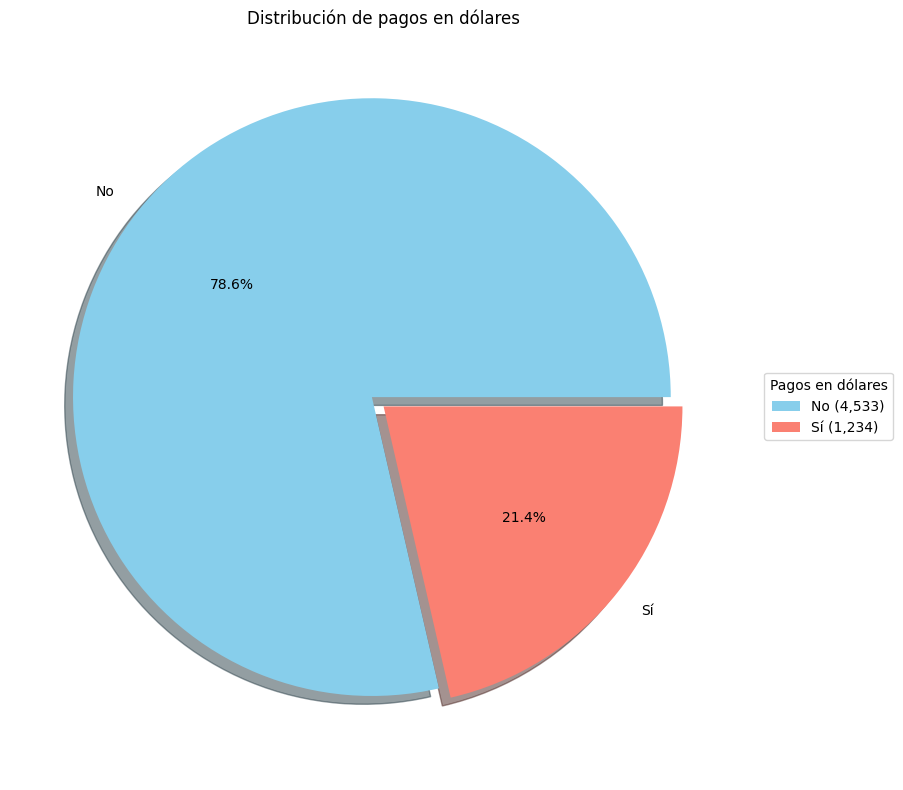

In [10]:
#Visualización de la distribución de pagos en dólares
pagos_en_dolares = empleabilidad2023['recibe_pagos_en_dolares'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(pagos_en_dolares, 
        labels=pagos_en_dolares.index,
        colors=['skyblue', 'salmon'],
        autopct='%1.1f%%',
        explode=[0.05, 0],
        shadow=True)
plt.title('Distribución de pagos en dólares')

# Agregar leyenda con valores absolutos
plt.legend(labels=[f'{index} ({value:,.0f})' 
                  for index, value in zip(pagos_en_dolares.index, pagos_en_dolares.values)],
          title="Pagos en dólares",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25304\1921792735.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  empleabilidad2023['Ultimo salario neto'] = pd.to_numeric(empleabilidad2023['Ultimo salario neto'], errors='coerce')


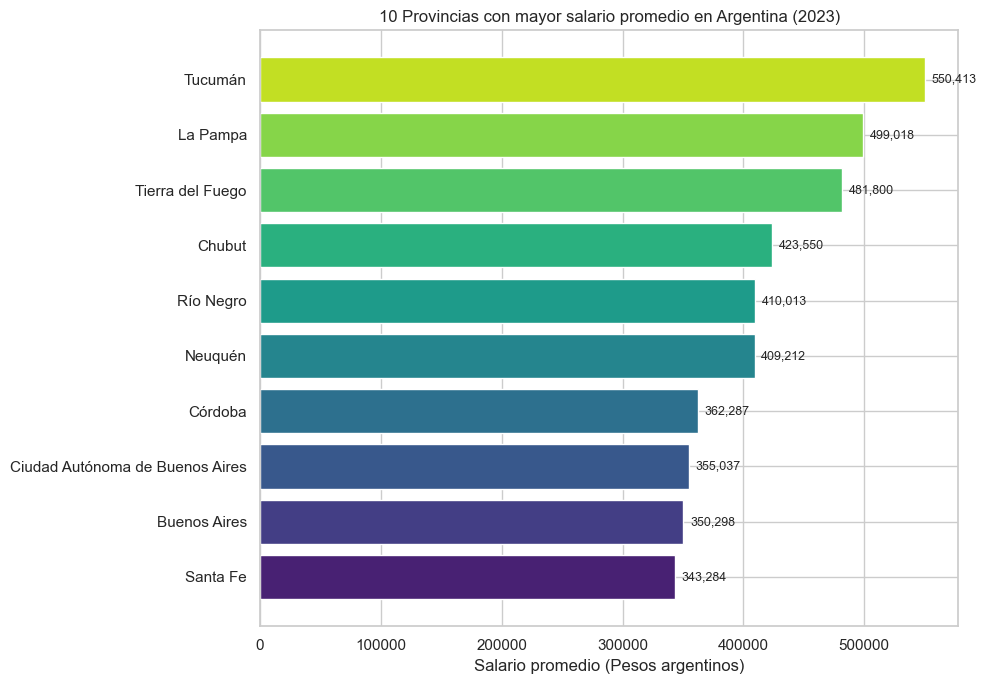

In [11]:
#Visualizacion de la mayor recaudacion por Provincia (10 mejores)
empleabilidad2023['Ultimo salario neto'] = pd.to_numeric(empleabilidad2023['Ultimo salario neto'], errors='coerce')
# calcular top 10 (ordenar y luego invertir para mostrar el mayor arriba)
provincias_top = (empleabilidad2023
                  .groupby('Lugar de trabajo')['Ultimo salario neto']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10)
                  .sort_values(ascending=True))  # invertir para barh

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))
colors = sns.color_palette("viridis", len(provincias_top))

bars = plt.barh(provincias_top.index, provincias_top.values, color=colors)
plt.xlabel('Salario promedio (Pesos argentinos)')
plt.title('10 Provincias con mayor salario promedio en Argentina (2023)')


# anotar valores al final de cada barra
for bar in bars:
    w = bar.get_width()
    plt.text(w + max(provincias_top.values)*0.01, bar.get_y() + bar.get_height()/2,
             f'{w:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
empleabilidad2023.tipo_de_contrato_laboral.value_counts()

tipo_de_contrato_laboral
Staff (planta permanente)                                 4502
Remoto (empresa de otro país)                              521
Tercerizado (trabajo a través de consultora o agencia)     505
Freelance                                                  199
Participación societaria en una cooperativa                 40
Name: count, dtype: int64

In [13]:
#Visualizacion de Trabajos por tipo de contrato laboral Freelance
contratos = empleabilidad2023['tipo_de_contrato_laboral'] == 'Freelance'
contratos = empleabilidad2023[contratos]['Profesion'].value_counts()
contratos


Profesion
Developer                          90
SysAdmin / DevOps / SRE            13
Technical Leader                   11
QA / Tester                        10
Consultant                          9
HelpDesk                            8
Project Manager                     6
Designer                            6
UX Designer                         6
Data Scientist                      6
Networking                          3
Manager / Director                  3
Recruiter / HR                      3
Business Analyst                    3
BI Analyst / Data Analyst           2
Product Manager                     2
Asistente de informática            1
DBA                                 1
basis SAP                           1
CTO                                 1
machine learning engineer           1
Finance                             1
Tecnicamente soy dev + PM + CTO     1
Technical Support                   1
UX Developer                        1
DEVOPS                              1
Co

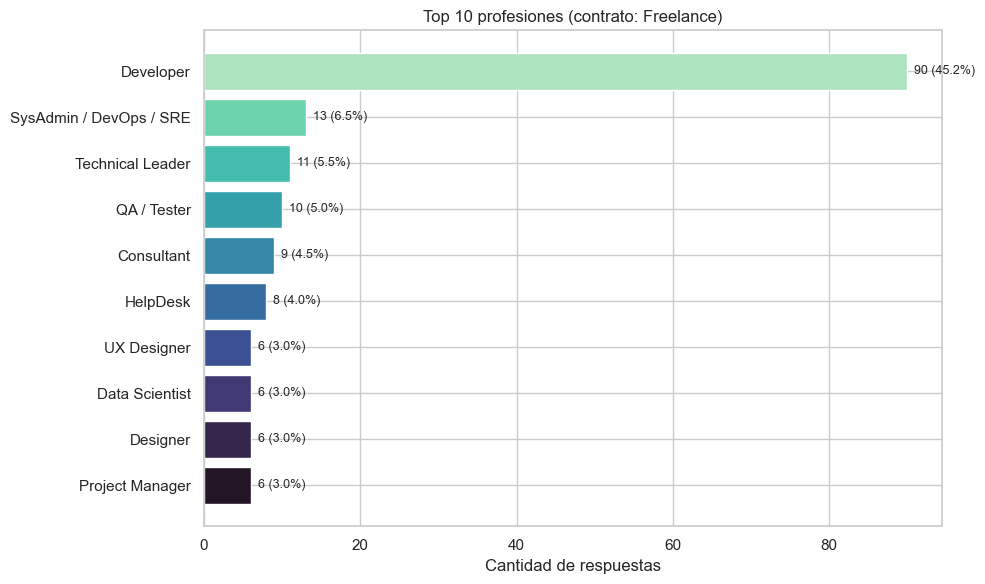

In [14]:
sns.set_theme(style="whitegrid")

# asegurar que 'contratos' es una serie de conteos
top10 = contratos.head(10).sort_values()  # ordenar ascendente para barh
total_freelance = contratos.sum()
pct = (top10 / total_freelance) * 100

plt.figure(figsize=(10, 6))
colors = sns.color_palette("mako", len(top10))
bars = plt.barh(top10.index, top10.values, color=colors)

plt.title('Top 10 profesiones (contrato: Freelance)')
plt.xlabel('Cantidad de respuestas')

# anotar conteo y porcentaje en cada barra
gap = max(top10.values) * 0.01
for bar, val, p in zip(bars, top10.values, pct):
    plt.text(val + gap, bar.get_y() + bar.get_height() / 2,
             f'{int(val):,} ({p:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
import sklearn 

In [ ]:
## HIPOTESIS DE CRECIMIENTO SALARIAL EN ARGENTINA
# Supongamos un crecimiento anual promedio del 30% (ajusta según contexto económico)
crecimiento_anual = 0.30
salario_2023 = empleabilidad2023['Ultimo salario neto'].mean()

# Proyección a 2028 (5 años)
salario_2028 = salario_2023 * ((1 + crecimiento_anual) ** 5)
print(f"Salario neto promedio proyectado para 2028: ${salario_2028:,.2f}")

Salario neto promedio proyectado para 2028: $1,308,678.61


In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Datos simulados siguiendo el crecimiento compuesto del 30% anual
salario_2023 = empleabilidad2023['Ultimo salario neto'].mean()
crecimiento_anual = 0.30
anios = np.array([2018, 2019, 2020, 2021, 2022, 2023]).reshape(-1, 1)
salarios = salario_2023 / ((1 + crecimiento_anual) ** (2023 - anios.flatten()))
salarios = salarios.astype(float)

# Modelo polinómico grado 2
poly = PolynomialFeatures(degree=2)
anios_poly = poly.fit_transform(anios)
modelo_poly = LinearRegression()
modelo_poly.fit(anios_poly, salarios)

# Predicción para 2028
anio_2028_poly = poly.transform(np.array([[2028]]))
salario_2028_poly = modelo_poly.predict(anio_2028_poly)[0]
print(f"Salario neto promedio proyectado para 2028 (Modelo polinómico): ${salario_2028_poly:,.2f}")

Salario neto promedio proyectado para 2028 (Modelo polinómico): $932,054.30
